In [2]:
# Cell 1: Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Cell 2: Extract Historical Financial Data
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

print(f"Fetching data for {tickers} from {start_date} to {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date)

# We will primarily focus on the 'Adj Close' prices for our analysis
# df_prices = data['Adj Close'].copy()
# # NEW CODE
df_prices = data['Close'].copy()
print("Data successfully fetched!")
display(df_prices.head())

Fetching data for ['TSLA', 'BND', 'SPY'] from 2015-01-01 to 2026-06-30...


[*********************100%***********************]  3 of 3 completed

Data successfully fetched!


Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,59.405403,169.687851,14.620667
2015-01-05,59.577908,166.623352,14.006000
2015-01-06,59.750439,165.053909,14.085333
2015-01-07,59.786350,167.110657,14.063333
2015-01-08,59.692936,170.076080,14.041333


In [3]:
# Cell 3: Basic Statistics & Data Types
print("--- Data Types ---")
print(df_prices.dtypes)

print("\n--- Basic Statistics ---")
display(df_prices.describe())

print("\n--- Missing Values Check ---")
print(df_prices.isnull().sum())

# Handling Missing Values (Forward fill, then backward fill for any remaining)
df_prices.ffill(inplace=True)
df_prices.bfill(inplace=True)

# Normalization/Scaling (Useful for certain ML models later)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_prices), columns=df_prices.columns, index=df_prices.index)
print("\n--- Normalized Data Preview ---")
display(df_scaled.head())

--- Data Types ---
Ticker
BND     float64
SPY     float64
TSLA    float64
dtype: object

--- Basic Statistics ---


Ticker,BND,SPY,TSLA
count,2888.000000,2888.000000,2888.000000
mean,66.503052,351.505533,148.773923
std,4.713606,155.443936,138.895957
min,58.729206,154.161636,9.578000
25%,62.478083,223.546776,18.393499
50%,65.728401,312.817886,133.437668
75%,70.689116,432.806831,251.925831
max,74.832901,757.618225,489.880005



--- Missing Values Check ---
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

--- Normalized Data Preview ---


Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,0.041990,0.025729,0.010499
2015-01-05,0.052702,0.020651,0.009219
2015-01-06,0.063416,0.018050,0.009384
2015-01-07,0.065646,0.021458,0.009339
2015-01-08,0.059845,0.026372,0.009293


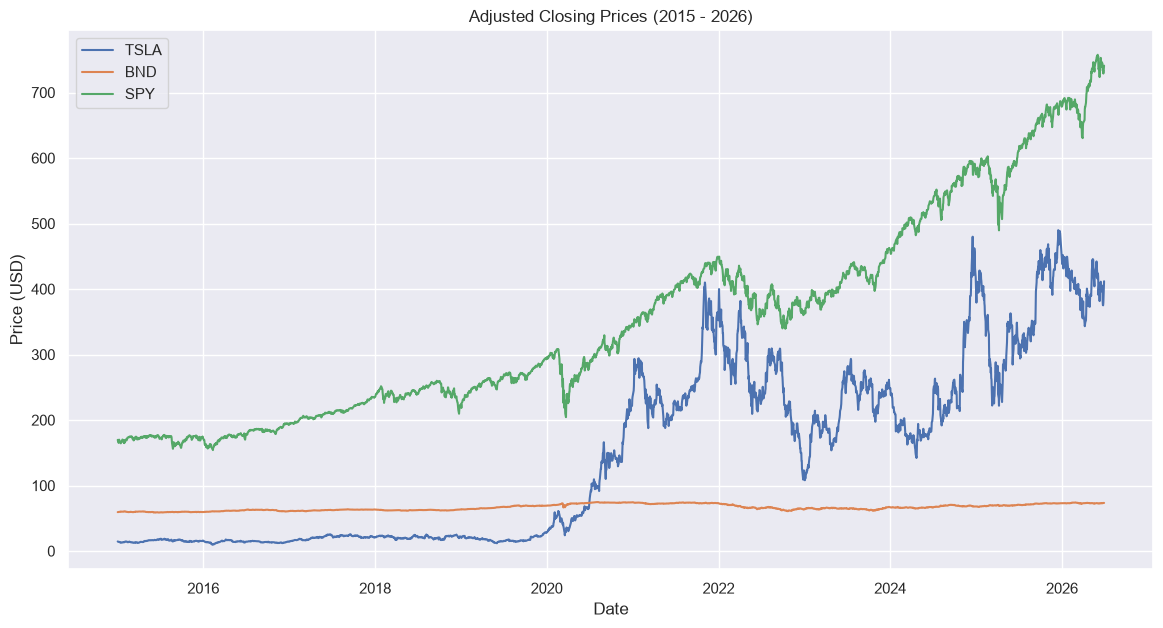

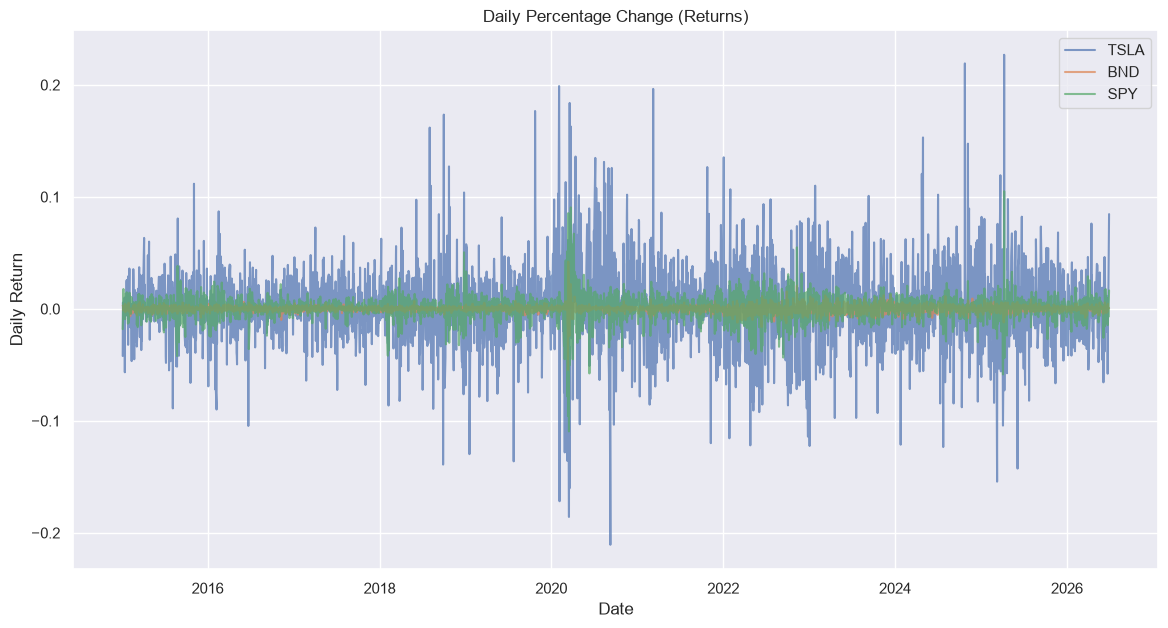

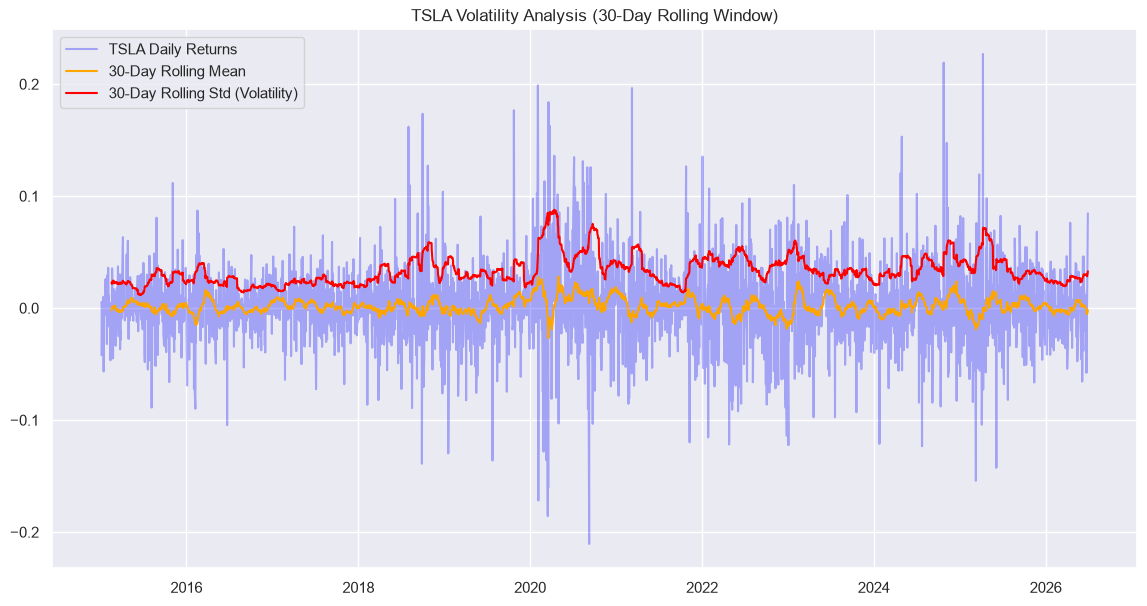

--- Outlier Detection (Days exceeding 3 Std Devs) ---
TSLA: 46 outlier days detected.
BND: 33 outlier days detected.
SPY: 39 outlier days detected.


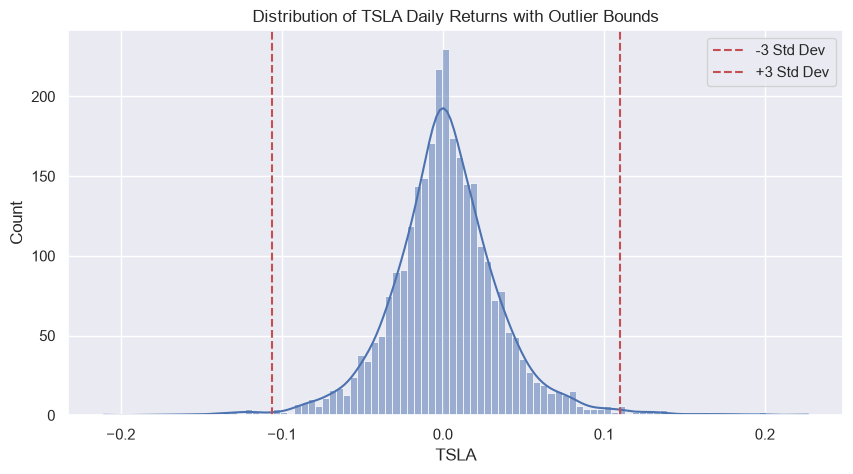

In [4]:
# Cell 4: Visualize Closing Prices over Time
plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(df_prices.index, df_prices[ticker], label=ticker)
plt.title('Adjusted Closing Prices (2015 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Cell 5: Calculate and Plot Daily Percentage Change (Returns)
df_returns = df_prices.pct_change().dropna()

plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(df_returns.index, df_returns[ticker], label=ticker, alpha=0.7)
plt.title('Daily Percentage Change (Returns)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()

# Cell 6: Rolling Means and Standard Deviations (Volatility Analysis for TSLA)
window = 30 # 30-day rolling window
tsla_returns = df_returns['TSLA']

plt.figure(figsize=(14, 7))
plt.plot(tsla_returns.index, tsla_returns, label='TSLA Daily Returns', alpha=0.3, color='blue')
plt.plot(tsla_returns.rolling(window=window).mean(), label=f'{window}-Day Rolling Mean', color='orange')
plt.plot(tsla_returns.rolling(window=window).std(), label=f'{window}-Day Rolling Std (Volatility)', color='red')
plt.title(f'TSLA Volatility Analysis ({window}-Day Rolling Window)')
plt.legend()
plt.show()

# Cell 7: Outlier Detection (Analyzing unusually high/low returns)
# Using 3 standard deviations as the threshold for an outlier
std_devs = df_returns.std()
means = df_returns.mean()

print("--- Outlier Detection (Days exceeding 3 Std Devs) ---")
for ticker in tickers:
    lower_bound = means[ticker] - (3 * std_devs[ticker])
    upper_bound = means[ticker] + (3 * std_devs[ticker])
    outliers = df_returns[(df_returns[ticker] < lower_bound) | (df_returns[ticker] > upper_bound)]
    print(f"{ticker}: {len(outliers)} outlier days detected.")

# Visualize TSLA distribution to see outliers
plt.figure(figsize=(10, 5))
sns.histplot(df_returns['TSLA'], bins=100, kde=True)
plt.axvline(means['TSLA'] - (3 * std_devs['TSLA']), color='r', linestyle='--', label='-3 Std Dev')
plt.axvline(means['TSLA'] + (3 * std_devs['TSLA']), color='r', linestyle='--', label='+3 Std Dev')
plt.title('Distribution of TSLA Daily Returns with Outlier Bounds')
plt.legend()
plt.show()

In [5]:
# Cell 8: Augmented Dickey-Fuller (ADF) Test
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test Results for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")
    if result[1] <= 0.05:
        print(f"Conclusion: {name} is STATIONARY (Reject Null Hypothesis)\n")
    else:
        print(f"Conclusion: {name} is NON-STATIONARY (Fail to Reject Null Hypothesis)\n")

# Test on Prices (Likely Non-Stationary)
print("TESTING PRICES (TRENDING DATA):")
for ticker in tickers:
    run_adf_test(df_prices[ticker], f"{ticker} Price")

# Test on Returns (Likely Stationary)
print("TESTING DAILY RETURNS (DIFFERENCED DATA):")
for ticker in tickers:
    run_adf_test(df_returns[ticker], f"{ticker} Returns")

TESTING PRICES (TRENDING DATA):
--- ADF Test Results for TSLA Price ---
ADF Statistic: -1.0696
p-value: 0.7270
Critical Values:
	1%: -3.4326
	5%: -2.8626
	10%: -2.5673
Conclusion: TSLA Price is NON-STATIONARY (Fail to Reject Null Hypothesis)

--- ADF Test Results for BND Price ---
ADF Statistic: -1.0827
p-value: 0.7219
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: BND Price is NON-STATIONARY (Fail to Reject Null Hypothesis)

--- ADF Test Results for SPY Price ---
ADF Statistic: 1.3089
p-value: 0.9967
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: SPY Price is NON-STATIONARY (Fail to Reject Null Hypothesis)

TESTING DAILY RETURNS (DIFFERENCED DATA):
--- ADF Test Results for TSLA Returns ---
ADF Statistic: -53.9719
p-value: 0.0000
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
Conclusion: TSLA Returns is STATIONARY (Reject Null Hypothesis)

--- ADF Test Results for BND Returns ---
ADF Statistic: -15.2161
p-value: 0.0000
Critical Valu

In [6]:
# Cell 9: Value at Risk (VaR) and Sharpe Ratio
risk_free_rate = 0.02 / 252 # Assuming a 2% annual risk-free rate, daily adjusted

print("--- Risk Metrics Summary ---")
for ticker in tickers:
    # Historical VaR (95% confidence level)
    # This means there is a 5% chance the asset will lose more than this percentage in a day
    var_95 = np.percentile(df_returns[ticker].dropna(), 5)
    
    # Sharpe Ratio (Annualized)
    # (Average Daily Return - Risk Free Rate) / Daily Std Dev * sqrt(252 trading days)
    avg_daily_return = df_returns[ticker].mean()
    daily_std = df_returns[ticker].std()
    sharpe_ratio = ((avg_daily_return - risk_free_rate) / daily_std) * np.sqrt(252)
    
    print(f"{ticker}:")
    print(f"  Historical VaR (95%): {var_95 * 100:.2f}%")
    print(f"  Annualized Sharpe Ratio: {sharpe_ratio:.2f}\n")

--- Risk Metrics Summary ---
TSLA:
  Historical VaR (95%): -5.17%
  Annualized Sharpe Ratio: 0.76

BND:
  Historical VaR (95%): -0.48%
  Annualized Sharpe Ratio: -0.00

SPY:
  Historical VaR (95%): -1.67%
  Annualized Sharpe Ratio: 0.70

